# Project 1 — Customer Support Ticket Analysis

**Crystal Olisa · Operations Generalist**

This notebook analyses a synthetic customer support dataset to demonstrate what becomes visible when you read both volume and resolution time — and what remains invisible when the classification system was built around how tickets were filed rather than what happened to the customer.

**Dataset:** [Kaggle — Customer Support Ticket Dataset by suraj520](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset)
**Posts:** Posts 4–7 of the LinkedIn content arc
**README:** [GitHub → Project 1](link)

---

### Key findings documented in this notebook

1. **Rank Shift** — Cancellation requests are the most disproportionately expensive category relative to volume (+3). Billing inquiry and Technical issue are the most efficient (-2).
2. **Deflection** — A significant proportion of inbound volume could have been resolved before it reached the team. Surfaced by reading description fields, not category labels.
3. **Taxonomy trap** — Cancellation requests and Refund requests may be measuring the same customer exit event twice. Neither metric reflects the true cost of customer exit.
4. **Satisfaction correlation** — Resolution time and satisfaction are functionally uncorrelated (r = -0.0035). The cost problem and the experience problem are separate investigations.

---

## Section 0 — Setup and load

**What we're doing:** Loading the dataset and inspecting its shape and columns.

**Why it matters:** Confirms the 8,469 ticket count and 17 available columns before any analysis begins. The column list tells us what is available to work with — and what is absent. There is no "customer exit journey" column. There is no column connecting a cancellation ticket to a subsequent refund ticket. Those absences are findings, not gaps.

In [1]:
# Load and inspect the data
import pandas as pd

df = pd.read_csv('../data/customer_support_tickets.csv')
print(df.shape)
print(df.columns.tolist())

(8469, 17)
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


## Section 1 — Initial inspection

**What we're doing:** Checking for null values, reviewing ticket type distribution, and confirming data types.

**Why it matters:** The null pattern is the first signal. 5,700 missing resolution times tells us immediately that most tickets are open or pending — not closed. This single observation shapes every subsequent analysis decision. We cannot calculate resolution time on open tickets. The analysis must be scoped to closed tickets only.

The near-uniform ticket type distribution (596 to 516 across five categories) is itself a signal. Real support queues cluster — everyday frictions dominate. This flat distribution tells us the volume chart will not be where the insight lives.

**Data quality note:** `Time to Resolution` is stored as object (string), not datetime. Conversion required before any time-based calculations.

In [2]:
print(df.head())
print()
print("Null counts:")
print(df.isnull().sum())
print()
print("Ticket type distribution (full dataset):")
print(df['Ticket Type'].value_counts())
print()
print("Time to Resolution dtype:", df['Time to Resolution'].dtype)

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

## Section 2 — Filter to closed tickets

**What we're doing:** Creating `df_closed` — the subset of tickets with status == 'Closed'.

**Why it matters:** Resolution time, satisfaction ratings, and first response times only exist for closed tickets. Open and pending tickets (5,700 of 8,469) are excluded from all resolution analysis.

This is a deliberate analytical decision, not a data cleaning step. The 5,700 excluded tickets are not errors — they are tickets in progress. Including them in resolution time analysis would produce meaningless results. All volume counts in this notebook use the full dataset (8,469) or the closed subset (2,769) depending on what is being measured.

**Key numbers after this filter:**
- Total dataset: 8,469 tickets
- Closed tickets (used for resolution analysis): 2,769
- Excluded (open/pending): 5,700

In [3]:
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])

df_closed = df[df['Ticket Status'] == 'Closed'].copy()

print(f"Total tickets: {len(df)}")
print(f"Closed tickets: {len(df_closed)}")
print(f"Open/pending tickets excluded: {len(df) - len(df_closed)}")

Total tickets: 8469
Closed tickets: 2769
Open/pending tickets excluded: 5700


## Section 3 — Calculate resolution hours and handle anomalies

**What we're doing:** Calculating resolution duration (First Response Time to Time to Resolution) and identifying timestamp anomalies.

**Why it matters — and why this decision needs to be documented:**

1,365 of 2,769 closed tickets produce negative resolution hours. This is a timestamp anomaly in the synthetic dataset — `Time to Resolution` was recorded before `First Response Time` in nearly half the closed records. This is not a real operational pattern. It is a data generation artefact.

**Decision made:** Tickets with negative resolution hours are excluded from all resolution time analysis. `df_clean` (1,404 records) is used for:
- Average resolution time per category
- Rank Shift calculation
- Resolution bucket analysis
- Satisfaction correlation

`df_closed` (2,769 records) is retained for:
- Volume counts per category
- Satisfaction scores (all closed tickets have a rating)
- Channel and priority distributions

This is the key data quality judgement call in this project. The negative values are excluded because they are artefacts, not because they are outliers. A real dataset with negative values would require investigation into the ticketing system's timestamp logic before exclusion.

In [4]:
# Calculate resolution hours
df_closed['resolution_hours'] = (
    df_closed['Time to Resolution'] - df_closed['First Response Time']
).dt.total_seconds() / 3600

# Document the anomaly
# NOTE: ~49% of closed tickets have negative resolution hours.
# This is a timestamp anomaly in the synthetic data — Time to Resolution
# was recorded before First Response Time. These are NOT real operational
# records. See markdown above for the full rationale for exclusion.
print("Tickets with negative resolution hours (timestamp anomalies):")
print(len(df_closed[df_closed['resolution_hours'] < 0]))
print("NOTE: These are excluded from resolution analysis — see markdown above.")
print()
print("Raw resolution hours distribution (including anomalies):")
print(df_closed['resolution_hours'].describe())
print()

# Filter to clean records — exclude timestamp anomalies
df_clean = df_closed[df_closed['resolution_hours'] >= 0].copy()

print(f"Clean records for resolution analysis: {len(df_clean)}")
print(f"Excluded (negative resolution hours): {len(df_closed) - len(df_clean)}")
print()
print("Resolution hours — clean records only:")
print(df_clean['resolution_hours'].describe())

Tickets with negative resolution hours (timestamp anomalies):
1365
NOTE: These are excluded from resolution analysis — see markdown above.

Raw resolution hours distribution (including anomalies):
count    2769.000000
mean       -0.057704
std         9.564112
min       -23.233333
25%        -6.933333
50%         0.166667
75%         6.483333
max        23.466667
Name: resolution_hours, dtype: float64

Clean records for resolution analysis: 1404
Excluded (negative resolution hours): 1365

Resolution hours — clean records only:
count    1404.000000
mean        7.577932
std         5.596637
min         0.000000
25%         3.000000
50%         6.341667
75%        11.354167
max        23.466667
Name: resolution_hours, dtype: float64


## Section 4 — Rank Shift analysis

**What we're doing:** Calculating volume rank, average resolution time rank, and Rank Shift per ticket category.

**Why it matters:** This is the core diagnostic concept of the project.

Volume rank tells you which categories arrive most often. Resolution rank tells you which categories take longest to resolve. **Rank Shift** is the gap between the two — a measure of how disproportionate a category's cost is relative to its volume.

**Formula:** `Rank Shift = Volume Rank − Resolution Rank`

- **Positive Rank Shift** → the category costs more than its volume predicts. It arrives less often than expected but consumes more resolution time per ticket.
- **Negative Rank Shift** → the category is more efficient than its volume predicts. It arrives more often but resolves faster relative to its share of the queue.
- **Zero** → volume rank and resolution rank are aligned. Cost is proportionate to volume.

**Data source for this analysis:**
- Volume: `df_closed` (2,769 closed tickets — full closed population)
- Average resolution hours: `df_clean` (1,404 records — anomalies excluded)

The two dataframes are merged on Ticket Type. This means volume and resolution time are calculated on different populations, which is documented above and consistent with the analytical decision in Section 3.

In [5]:
# Volume — use full closed dataset (all 2,769 closed tickets)
volume = df_closed['Ticket Type'].value_counts().reset_index()
volume.columns = ['Ticket Type', 'Count']

# Average resolution time — use clean dataset only (1,404 records)
avg_resolution = df_clean.groupby('Ticket Type')['resolution_hours'].mean().reset_index()
avg_resolution.columns = ['Ticket Type', 'Avg Resolution Hours']

# Merge into one summary table
summary = volume.merge(avg_resolution, on='Ticket Type')
summary = summary.sort_values('Count', ascending=False)

# Calculate Rank Shift
summary['Volume Rank'] = summary['Count'].rank(ascending=False).astype(int)
summary['Resolution Rank'] = summary['Avg Resolution Hours'].rank(ascending=False).astype(int)
summary['Rank Shift'] = summary['Volume Rank'] - summary['Resolution Rank']

print("Rank Shift by ticket category:")
print(summary[['Ticket Type', 'Count', 'Avg Resolution Hours',
               'Volume Rank', 'Resolution Rank', 'Rank Shift']].to_string(index=False))
print()
print("Key finding: Cancellation request has the lowest volume (rank 5)")
print("but the second highest average resolution time (rank 2) — Rank Shift +3.")
print("Billing inquiry and Technical issue both sit at -2: more efficient than volume predicts.")

Rank Shift by ticket category:
         Ticket Type  Count  Avg Resolution Hours  Volume Rank  Resolution Rank  Rank Shift
      Refund request    596              8.117818            1                1           0
     Technical issue    580              7.365191            2                4          -2
     Billing inquiry    544              7.010256            3                5          -2
     Product inquiry    533              7.676070            4                3           1
Cancellation request    516              7.693082            5                2           3

Key finding: Cancellation request has the lowest volume (rank 5)
but the second highest average resolution time (rank 2) — Rank Shift +3.
Billing inquiry and Technical issue both sit at -2: more efficient than volume predicts.


## Section 5 — Total resolution hours

**What we're doing:** Calculating total hours consumed per category (count × average hours) and adding this to the summary table.

**Why it matters:** Average resolution time tells you how long each ticket takes. Total resolution hours tells you what the business actually pays.

A category with moderate average resolution time but high volume can consume more total hours than a category with high average time but low volume. Looking at averages alone misses this.

**The key number:** Cancellation requests — 3,970 total hours on 516 tickets. This is not the highest total in the dataset (Refund request at 4,838 is higher). But it is the most disproportionate relative to volume — the Rank Shift of +3 is the largest gap in the dataset.

This is also where the taxonomy trap becomes visible. Refund request (4,838 hours) and Cancellation request (3,970 hours) may be measuring the same customer exit event twice. The combined total of 8,808 hours may include duplicated customer journeys that the taxonomy cannot see as connected.

In [6]:
# Add total resolution hours to the summary table
summary['Total Resolution Hours'] = (summary['Count'] * summary['Avg Resolution Hours']).round(0)

print("Summary with total resolution hours:")
print(summary[['Ticket Type', 'Count', 'Avg Resolution Hours',
               'Total Resolution Hours', 'Rank Shift']].to_string(index=False))
print()
print("Note: Cancellation request and Refund request combined = 8,808 total hours.")
print("If 30-50% of cancellations generate a subsequent refund request,")
print("neither figure reflects the true cost of customer exit independently.")
print()

# --- FTE conversion ---
# 8,808 combined exit-category hours translated into headcount equivalent.
# Assumption: 1 FTE = ~1,800 productive working hours per year
# (52 weeks × 40 hours, minus ~10% for leave, meetings, overhead)
exit_hours = summary.loc[
    summary['Ticket Type'].isin(['Cancellation request', 'Refund request']),
    'Total Resolution Hours'
].sum()

working_hours_per_fte = 1800
fte_equivalent = exit_hours / working_hours_per_fte

# Loaded cost estimate: $60k-$80k fully loaded per support FTE (salary + benefits + tooling)
cost_low = fte_equivalent * 60_000
cost_high = fte_equivalent * 80_000

print(f"Exit-category total hours (Cancellation + Refund): {exit_hours:,.0f}")
print(f"FTE equivalent (@1,800 hrs/year): {fte_equivalent:.1f} FTEs")
print(f"Estimated annual cost: ${cost_low:,.0f}-${cost_high:,.0f}")
print()
print("Interpretation: approximately 4.9 full-time employees are occupied exclusively")
print("processing customer exits. At a loaded cost of $60k-$80k per support FTE,")
print("this is a $290k-$390k annual line item — before accounting for the CAC cost")
print("of the customers being lost. This is not a support efficiency problem.")
print("It is a retention problem with a support cost attached to it.")

Summary with total resolution hours:
         Ticket Type  Count  Avg Resolution Hours  Total Resolution Hours  Rank Shift
      Refund request    596              8.117818                  4838.0           0
     Technical issue    580              7.365191                  4272.0          -2
     Billing inquiry    544              7.010256                  3814.0          -2
     Product inquiry    533              7.676070                  4091.0           1
Cancellation request    516              7.693082                  3970.0           3

Note: Cancellation request and Refund request combined = 8,808 total hours.
If 30-50% of cancellations generate a subsequent refund request,
neither figure reflects the true cost of customer exit independently.

Exit-category total hours (Cancellation + Refund): 8,808
FTE equivalent (@1,800 hrs/year): 4.9 FTEs
Estimated annual cost: $293,600-$391,467

Interpretation: approximately 4.9 full-time employees are occupied exclusively
processing cu

### Chart 1 — Total resolution hours coloured by Rank Shift

**What we're doing:** Plotting total resolution hours per category as a horizontal bar chart, coloured by Rank Shift value.

**Why it matters:** The table above shows the numbers. This chart shows the anomaly — the lowest-volume category has the longest orange bar. Colour carries the same meaning as in all data visualisation in this project: orange = positive Rank Shift (costs more than volume predicts), green = negative (more efficient), grey = zero (proportionate).

Each bar label shows both total hours and Rank Shift value so the chart is self-contained if screenshotted or shared without context.

**Saved to:** `../charts/chart_1_rank_shift.png` — referenced in the README under Finding 1 and used as the Post 6 visual.

**Note:** Data is pulled directly from the `summary` dataframe built in this section so the chart is always consistent with what the analysis produced.

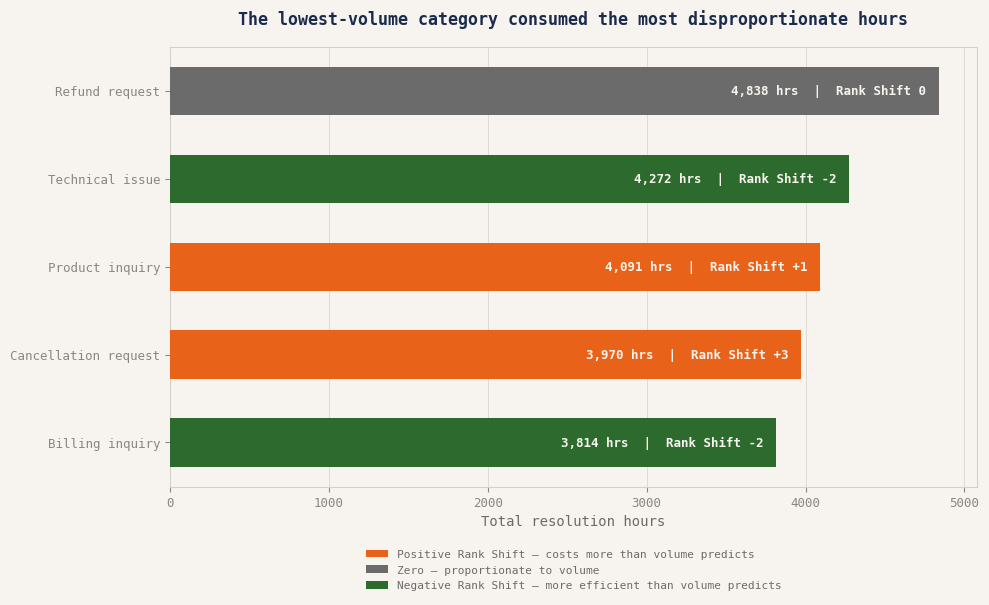

Saved: charts/chart_1_rank_shift.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

os.makedirs('../charts', exist_ok=True)

# --- data pulled from summary dataframe (not hardcoded) ---
categories = summary['Ticket Type'].tolist()
total_hours = summary['Total Resolution Hours'].tolist()
rank_shifts = summary['Rank Shift'].tolist()

# Colour by Rank Shift semantics
# Orange = positive (more expensive than volume predicts)
# Mid grey = zero (proportionate)
# Green = negative (more efficient than volume predicts)
bar_colors = []
for rs in rank_shifts:
    if rs > 0:
        bar_colors.append('#E8621A')
    elif rs < 0:
        bar_colors.append('#2D6A2D')
    else:
        bar_colors.append('#6B6B6B')

# Sort by total hours descending for visual clarity
order = sorted(range(len(total_hours)), key=lambda i: total_hours[i], reverse=True)
categories_sorted = [categories[i] for i in order]
hours_sorted      = [total_hours[i] for i in order]
colors_sorted     = [bar_colors[i] for i in order]
shifts_sorted     = [rank_shifts[i] for i in order]

# --- style ---
matplotlib.rcParams['font.family'] = 'monospace'
fig, ax = plt.subplots(figsize=(10, 6.2))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

bars = ax.barh(categories_sorted, hours_sorted, color=colors_sorted,
               height=0.55, zorder=3)

# Labels on bars: total hours + Rank Shift
for bar, hrs, rs, col in zip(bars, hours_sorted, shifts_sorted, colors_sorted):
    label_color = '#F7F4EF'
    rs_label = f'+{rs}' if rs > 0 else str(rs)
    ax.text(
        hrs - 80,
        bar.get_y() + bar.get_height() / 2,
        f'{hrs:,.0f} hrs  |  Rank Shift {rs_label}',
        ha='right', va='center',
        fontsize=9, color=label_color,
        fontfamily='monospace', fontweight='bold'
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E8621A', label='Positive Rank Shift — costs more than volume predicts'),
    Patch(facecolor='#6B6B6B', label='Zero — proportionate to volume'),
    Patch(facecolor='#2D6A2D', label='Negative Rank Shift — more efficient than volume predicts'),
]
ax.legend(handles=legend_elements, loc='upper center',
          bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=8,
          framealpha=0, labelcolor='#6B6B6B')

# Formatting
ax.set_xlabel('Total resolution hours', fontsize=10, color='#6B6B6B',
               fontfamily='monospace')
ax.set_title(
    'The lowest-volume category consumed the most disproportionate hours',
    fontsize=12, fontweight='bold', color='#1A2B4B',
    fontfamily='monospace', pad=16
)
ax.tick_params(colors='#888780', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#D3D1C7')
ax.xaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../charts/chart_1_rank_shift.png', dpi=150,
            bbox_inches='tight', facecolor='#F7F4EF')
plt.show()
print("Saved: charts/chart_1_rank_shift.png")

## Section 6 — First response time by ticket type

**What we're doing:** Calculating the average hour of day when first responses are sent, by ticket type.

**Why it matters (exploratory):** This analysis was included to check whether certain ticket types receive faster first responses than others — which would suggest informal triage by agent preference rather than a formal routing system.

**Finding:** All five categories cluster tightly around 11am (11.24 to 11.46 average hour). There is no meaningful differentiation. This is consistent with the synthetic dataset's uniform distribution and does not produce a post finding. Included for completeness.

**What this would mean in a real dataset:** If Cancellation requests consistently received first responses later in the day than Technical issues, it would indicate agents are deprioritising them informally — routing without a routing rule. That is an operational decision being made by individuals that the taxonomy has not yet named. In a real operation, first response time by category is one of the earliest signals that informal triage has replaced documented process.

**No finding derived from this section for the README or posts.**

In [8]:
avg_frt = df_closed.groupby('Ticket Type')['First Response Time'].apply(
    lambda x: x.dt.hour.mean()
).reset_index()
avg_frt.columns = ['Ticket Type', 'Avg First Response Hour of Day']
avg_frt = avg_frt.sort_values('Avg First Response Hour of Day')

print("Average first response hour by ticket type:")
print(avg_frt.to_string(index=False))
print()
print("Note: All categories cluster around 11am (11.24-11.46).")
print("No meaningful differentiation. Consistent with synthetic data.")

Average first response hour by ticket type:
         Ticket Type  Avg First Response Hour of Day
     Billing inquiry                       11.235294
     Product inquiry                       11.281426
Cancellation request                       11.393411
     Technical issue                       11.455172
      Refund request                       11.463087

Note: All categories cluster around 11am (11.24-11.46).
No meaningful differentiation. Consistent with synthetic data.


## Section 7 — Priority analysis

**What we're doing:** Analysing resolution time and ticket type distribution by ticket priority (Critical, High, Medium, Low).

**Why it matters (exploratory):** In a real operation, priority should predict resolution time — Critical tickets should resolve faster than Low priority tickets. If it does not, the priority system is not functioning as intended.

**Finding:** Priority does not predict resolution time in this dataset. High priority tickets (mean 8.07 hours) take longer than Critical (mean 7.15 hours). The priority distribution across ticket types is also near-uniform — each type has roughly equal proportions of Critical, High, Medium, and Low tickets. This is consistent with the synthetic dataset's flat distribution. Priority assignment appears random rather than systematic.

**What this would mean in a real dataset:** High priority tickets resolving slower than Critical is not a curiosity — it is a signal that the routing system is not functioning as intended. Either agents are not routing by priority, the SLA definitions are unclear, or the tool configuration does not enforce the priority order. Any of these would mean the priority field is decorative rather than operational. Before building any SLA framework or escalation logic on top of this data, you would need to investigate whether the priority assignment is consistent and whether it is actually connected to routing behaviour. A priority field that does not predict resolution time should not be used as a metric.

**No finding derived from this section for the README or posts.**

In [9]:
print("Ticket count by priority (closed tickets):")
print(df_closed['Ticket Priority'].value_counts())
print()

priority_res = df_clean.groupby('Ticket Priority')['resolution_hours'].agg(
    Count='count',
    Mean='mean',
    Median='median'
).round(2).sort_values('Mean', ascending=False)

print("Resolution time by priority (clean records):")
print(priority_res.to_string())
print()
print("Note: Priority does not predict resolution time. High > Critical.")
print("Priority distribution across ticket types is near-uniform — consistent with synthetic data.")
print()

priority_type = pd.crosstab(
    df_closed['Ticket Type'],
    df_closed['Ticket Priority'],
    normalize='index'
).round(3) * 100

print("Priority distribution by ticket type (% of each type):")
print(priority_type.to_string())

Ticket count by priority (closed tickets):
Ticket Priority
Critical    726
High        705
Medium      694
Low         644
Name: count, dtype: int64

Resolution time by priority (clean records):
                 Count  Mean  Median
Ticket Priority                     
High               355  8.07    7.12
Low                334  7.95    7.08
Medium             341  7.17    5.87
Critical           374  7.15    5.98

Note: Priority does not predict resolution time. High > Critical.
Priority distribution across ticket types is near-uniform — consistent with synthetic data.

Priority distribution by ticket type (% of each type):
Ticket Priority       Critical  High   Low  Medium
Ticket Type                                       
Billing inquiry           26.3  24.8  24.4    24.4
Cancellation request      28.1  24.0  20.3    27.5
Product inquiry           27.0  24.6  22.1    26.3
Refund request            24.7  26.5  25.2    23.7
Technical issue           25.3  27.1  23.8    23.8


## Section 8 — Channel analysis

**What we're doing:** Analysing resolution time and ticket type distribution by inbound channel (Email, Phone, Social media, Chat).

**Why it matters (exploratory):** Channel can predict resolution time in real operations — asynchronous channels (email) often have higher resolution times than synchronous channels (phone, chat) because of back-and-forth delays. If Social media takes longest, it may reflect routing inefficiency, agent familiarity, or platform-specific response constraints.

**Finding:** Social media has the highest mean resolution time (7.91 hours) and Phone the lowest (7.26 hours). The difference is less than one hour across all four channels. Ticket type distribution across channels is near-uniform — consistent with the synthetic dataset.

**What this would mean in a real dataset:** A 0.65 hour gap between Social media and Phone may look small in aggregate, but if Cancellation requests arriving via Social media take significantly longer than the same type arriving via Phone, the channel is amplifying an existing process gap rather than creating a new one. The channel analysis earns its value when cross-tabulated against ticket type and resolution time simultaneously — not as a standalone view. In a real operation, if Social media consistently takes longest, the intervention is not "hire more Social media agents" — it is to investigate whether Social media tickets are being routed to the same queue as Phone tickets or handled by agents who also manage other channels. The routing decision, not the channel itself, is usually the lever.

**No finding derived from this section for the README or posts.**

In [10]:
print("Ticket count by channel (closed tickets):")
print(df_closed['Ticket Channel'].value_counts())
print()

channel_res = df_clean.groupby('Ticket Channel')['resolution_hours'].agg(
    Count='count',
    Mean='mean',
    Median='median'
).round(2).sort_values('Mean', ascending=False)

print("Resolution time by channel (clean records):")
print(channel_res.to_string())
print()
print("Note: Social media takes longest (7.91h) vs Phone (7.26h).")
print("Difference < 1hr across all channels. Near-uniform distribution consistent with synthetic data.")
print()

channel_type = pd.crosstab(
    df_closed['Ticket Channel'],
    df_closed['Ticket Type']
)

print("Ticket type distribution by channel:")
print(channel_type.to_string())

Ticket count by channel (closed tickets):
Ticket Channel
Email           720
Phone           691
Social media    684
Chat            674
Name: count, dtype: int64

Resolution time by channel (clean records):
                Count  Mean  Median
Ticket Channel                     
Social media      348  7.91    6.43
Email             374  7.62    6.41
Chat              355  7.50    6.52
Phone             327  7.26    6.05

Note: Social media takes longest (7.91h) vs Phone (7.26h).
Difference < 1hr across all channels. Near-uniform distribution consistent with synthetic data.

Ticket type distribution by channel:
Ticket Type     Billing inquiry  Cancellation request  Product inquiry  Refund request  Technical issue
Ticket Channel                                                                                         
Chat                        137                   136              116             143              142
Email                       134                   154              126

## Section 9 — Satisfaction analysis

**What we're doing:** Analysing customer satisfaction rating distribution, satisfaction by ticket type, and satisfaction by priority.

**Why it matters:** Satisfaction scores set up the correlation analysis in Section 10. The key question is: does the category with the highest cost also have the lowest satisfaction? If yes, cost and experience are aligned. If no, they are separate problems requiring separate investigations.

**Key findings from this section:**

- **Refund request** has the lowest satisfaction (2.935) AND the highest absolute cost (4,838 total hours). At first glance this suggests cost and experience are aligned for this category.
- **Cancellation request** has the highest satisfaction (3.029) despite being the most disproportionately expensive category by Rank Shift (+3).
- **The spread across all five categories is less than 0.1 points** (2.935 to 3.029). Resolution time is not moving that number — if it were, we would expect more variance.

**The taxonomy trap note:** Refund request's low satisfaction may not reflect slow refund processing. It may reflect that customers who filed a refund request had already been through the cancellation process first. The satisfaction score is measuring the end of a journey the taxonomy treats as a beginning.

**Data source:** `df_closed` (all 2,769 closed tickets). All closed tickets have a satisfaction rating — no missing values here.

In [11]:
print("Customer satisfaction rating distribution (closed tickets):")
print(df_closed['Customer Satisfaction Rating'].value_counts().sort_index())
print()
print(f"Mean satisfaction: {df_closed['Customer Satisfaction Rating'].mean():.3f}")
print(f"Tickets with rating: {df_closed['Customer Satisfaction Rating'].notna().sum()}")
print(f"Tickets without rating: {df_closed['Customer Satisfaction Rating'].isna().sum()}")
print()

sat_by_type = df_closed.groupby('Ticket Type')['Customer Satisfaction Rating'].agg(
    Mean='mean',
    Count='count'
).round(3).sort_values('Mean')

print("Average satisfaction by ticket type (sorted lowest to highest):")
print(sat_by_type.to_string())
print()
print("Note: Spread = 2.935 to 3.029. Less than 0.1 points across all categories.")
print("Resolution time is not what is moving this number.")
print()

sat_by_priority = df_closed.groupby('Ticket Priority')['Customer Satisfaction Rating'].agg(
    Mean='mean',
    Count='count'
).round(3).sort_values('Mean')

print("Average satisfaction by priority:")
print(sat_by_priority.to_string())

Customer satisfaction rating distribution (closed tickets):
Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544
Name: count, dtype: int64

Mean satisfaction: 2.991
Tickets with rating: 2769
Tickets without rating: 0

Average satisfaction by ticket type (sorted lowest to highest):
                       Mean  Count
Ticket Type                       
Refund request        2.935    596
Technical issue       2.959    580
Product inquiry       3.017    533
Billing inquiry       3.028    544
Cancellation request  3.029    516

Note: Spread = 2.935 to 3.029. Less than 0.1 points across all categories.
Resolution time is not what is moving this number.

Average satisfaction by priority:
                  Mean  Count
Ticket Priority              
Critical         2.959    726
Medium           2.977    694
High             2.983    705
Low              3.053    644


## Section 10 — Final summary and satisfaction correlation

**What we're doing:** Building a combined summary table across all dimensions (volume, average resolution, total resolution, Rank Shift, satisfaction) and calculating the Pearson correlation between resolution hours and satisfaction scores.

**Why it matters:** This is the payoff of the full analysis. The combined table shows every category's position on every metric simultaneously — making the Rank Shift anomaly, the satisfaction inversion, and the taxonomy trap all visible in one view.

**The correlation finding:**

r = −0.0035. Functionally zero.

This means resolution time and satisfaction are uncorrelated in this dataset. The assumption that faster resolution produces higher satisfaction is not supported by the data. This is not a proof that speed never matters — it is a finding specific to this dataset. But it changes the investment question: if speed and satisfaction are uncorrelated, resources spent reducing handle time have had no measurable effect on customer experience.

**The 6-12 hour satisfaction spike — and the escalation hypothesis:**

The bucket analysis (below) shows that the 6-12 hour bucket scores highest (3.126), while the fastest bucket (0-3 hours) scores no better than the 3-6 hour bucket (2.997). This is the counterintuitive finding inside the correlation result.

One explanation is the escalation hypothesis: tickets that take 6-12 hours may not be slow because they're difficult — they may be slow because they've been escalated to senior agents who actually resolve the root cause, whereas 0-3 hour tickets are handled quickly but not deeply. If that's true, speed is a proxy for agent tier, not a lever for satisfaction. The correct intervention is not faster first-response; it is better first-contact resolution at the frontline level.

**What this would mean in a real dataset:** To test the escalation hypothesis, you would need agent tier data (L1 vs L2), escalation flags, and first-contact resolution rates. If escalated tickets cluster in the 6-12 hour bucket and score consistently higher than non-escalated tickets in the same time range, the hypothesis holds. That would reframe the hiring and training question entirely: the investment goes into frontline agent quality, not headcount.

In the absence of that data, the escalation hypothesis remains a candidate explanation. What the data does rule out is the standard assumption — that shaving response time will lift satisfaction scores.

**Methodological note:** Correlation is calculated using `df_clean` for resolution hours (1,404 records with valid timestamps) joined to satisfaction scores via index alignment with `df_closed`. This is the correct approach — the index of `df_clean` is a subset of `df_closed`'s index, so `df_closed.loc[df_clean.index]` retrieves the matching satisfaction scores accurately.

The broken version of this cell (using a Ticket ID merge that failed with a KeyError) has been removed. The working approach below uses index alignment.

In [12]:
# Build final combined summary
final_summary = summary[['Ticket Type', 'Count', 'Avg Resolution Hours',
                           'Total Resolution Hours', 'Rank Shift']].copy()

# Add satisfaction scores from df_closed (full closed population)
sat_means = df_closed.groupby('Ticket Type')['Customer Satisfaction Rating'].mean().round(3)
final_summary = final_summary.merge(
    sat_means.reset_index().rename(columns={'Customer Satisfaction Rating': 'Avg Satisfaction'}),
    on='Ticket Type'
)

# Add satisfaction rank
final_summary['Sat Rank'] = final_summary['Avg Satisfaction'].rank(ascending=False).astype(int)
final_summary = final_summary.sort_values('Total Resolution Hours', ascending=False)

print("Final summary — all dimensions:")
print(final_summary.to_string(index=False))
print()

# Satisfaction correlation — index alignment approach
# df_clean is a subset of df_closed. We align satisfaction scores
# via index to ensure each resolution time record matches its
# corresponding satisfaction score.

correlation = df_clean['resolution_hours'].corr(
    df_closed.loc[df_clean.index, 'Customer Satisfaction Rating']
)

print(f"Correlation: resolution hours vs customer satisfaction: {correlation:.4f}")
print("(negative = longer resolution = lower satisfaction, positive = opposite)")
print()
print(f"Interpretation: r = {correlation:.4f} is functionally zero.")
print("Resolution time does not predict satisfaction in this dataset.")
print("The cost problem and the experience problem are separate investigations.")
print()

# Resolution time bucket analysis
import pandas as pd

df_corr = df_clean.copy()
df_corr['Satisfaction'] = df_closed.loc[df_clean.index, 'Customer Satisfaction Rating']

df_corr['Resolution Bucket'] = pd.cut(
    df_corr['resolution_hours'],
    bins=[0, 3, 6, 12, 24],
    labels=['0-3 hrs', '3-6 hrs', '6-12 hrs', '12-24 hrs']
)

bucket_summary = df_corr.groupby('Resolution Bucket', observed=True)['Satisfaction'].agg(
    Count='count',
    Mean='mean'
).round(3)

print("Average satisfaction by resolution time bucket:")
print(bucket_summary.to_string())
print()
print("Key finding: 6-12 hour bucket scores HIGHEST (3.126).")
print("Fastest bucket (0-3 hrs) scores 2.997 — identical to 3-6 hrs.")
print("Speed did not produce better outcomes.")

Final summary — all dimensions:
         Ticket Type  Count  Avg Resolution Hours  Total Resolution Hours  Rank Shift  Avg Satisfaction  Sat Rank
      Refund request    596              8.117818                  4838.0           0             2.935         5
     Technical issue    580              7.365191                  4272.0          -2             2.959         4
     Product inquiry    533              7.676070                  4091.0           1             3.017         3
Cancellation request    516              7.693082                  3970.0           3             3.029         1
     Billing inquiry    544              7.010256                  3814.0          -2             3.028         2

Correlation: resolution hours vs customer satisfaction: -0.0035
(negative = longer resolution = lower satisfaction, positive = opposite)

Interpretation: r = -0.0035 is functionally zero.
Resolution time does not predict satisfaction in this dataset.
The cost problem and the experie

### Chart 2 — Satisfaction scatter plot

**What we're doing:** Plotting resolution hours (x) against satisfaction rating (y) with a trend line.

**Why it matters:** The near-flat trend line makes the correlation finding visible in a way the r-value alone cannot. A scatter of 1,404 points with no discernible pattern is more convincing to a technical founder than a single number. The chart is saved to `../charts/chart_2_satisfaction_scatter.png` for the GitHub README and Post 7.

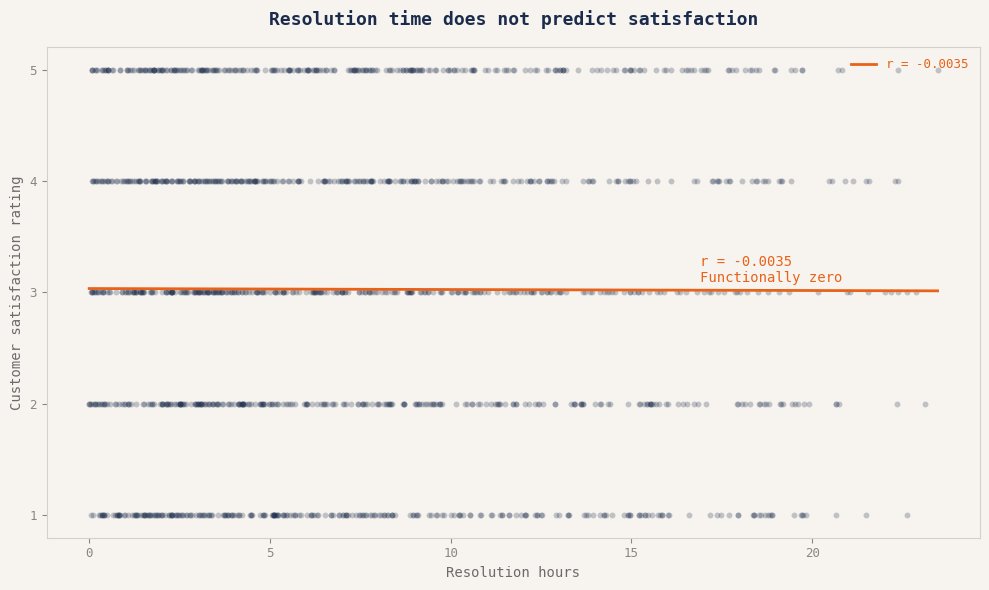

Saved: charts/chart_2_satisfaction_scatter.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

os.makedirs('../charts', exist_ok=True)

# --- data ---
x = df_corr['resolution_hours'].values
y = df_corr['Satisfaction'].values

# trend line
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

# --- style ---
matplotlib.rcParams['font.family'] = 'monospace'
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

# scatter
ax.scatter(x, y, alpha=0.25, s=18, color='#1A2B4B', linewidths=0)

# trend line
ax.plot(x_line, y_line, color='#E8621A', linewidth=2, label=f'r = {correlation:.4f}')

# annotation
ax.annotate(
    f'r = {correlation:.4f}\nFunctionally zero',
    xy=(x.max() * 0.72, y_line[-1] + 0.08),
    fontsize=10,
    color='#E8621A',
    fontfamily='monospace'
)

# formatting
ax.set_xlabel('Resolution hours', fontsize=10, color='#6B6B6B', fontfamily='monospace')
ax.set_ylabel('Customer satisfaction rating', fontsize=10, color='#6B6B6B', fontfamily='monospace')
ax.set_title(
    'Resolution time does not predict satisfaction',
    fontsize=13, fontweight='bold', color='#1A2B4B',
    fontfamily='monospace', pad=16
)
ax.tick_params(colors='#888780', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#D3D1C7')
ax.legend(fontsize=9, framealpha=0, labelcolor='#E8621A')
ax.set_yticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('../charts/chart_2_satisfaction_scatter.png', dpi=150, bbox_inches='tight',
            facecolor='#F7F4EF')
plt.show()
print("Saved: charts/chart_2_satisfaction_scatter.png")

### Chart 3 — Satisfaction by resolution time bucket

**What we're doing:** Plotting average satisfaction per resolution time bucket as a bar chart.

**Why it matters:** The bucket chart makes the non-linear pattern visible — the 6-12 hour bucket scores highest, the 0-3 and 3-6 buckets are identical, and the 12-24 bucket drops back. A table can show these numbers but the visual makes the non-linearity immediately obvious. The orange bar is the counterintuitive finding. The chart is saved to `../charts/chart_3_satisfaction_by_bucket.png`.

**Note on y-axis range:** The axis is set to 2.90-3.20 deliberately. The actual spread is only 0.15 points. Without the tight range the bars would look nearly identical and the finding would be invisible.

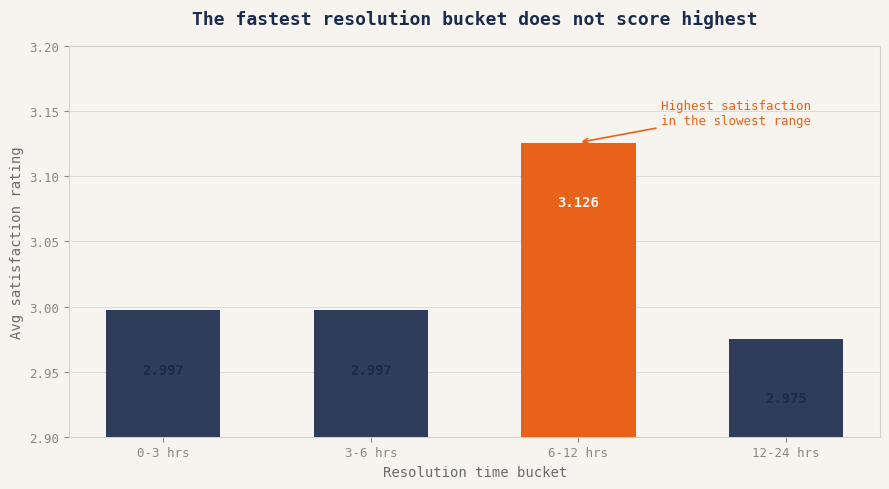

Saved: charts/chart_3_satisfaction_by_bucket.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# --- data from bucket_summary ---
buckets = ['0-3 hrs', '3-6 hrs', '6-12 hrs', '12-24 hrs']
means   = [2.997, 2.997, 3.126, 2.975]
colors  = ['#2E3E5A', '#2E3E5A', '#E8621A', '#2E3E5A']

# --- style ---
matplotlib.rcParams['font.family'] = 'monospace'
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F7F4EF')
ax.set_facecolor('#F7F4EF')

bars = ax.bar(buckets, means, color=colors, width=0.55, zorder=3)

# value labels on bars
for bar, val, col in zip(bars, means, colors):
    label_color = '#F7F4EF' if col == '#E8621A' else '#1A2B4B'
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() - 0.04,
        f'{val:.3f}',
        ha='center', va='top',
        fontsize=10, color=label_color,
        fontfamily='monospace', fontweight='bold'
    )

# annotation on orange bar
ax.annotate(
    'Highest satisfaction\nin the slowest range',
    xy=(2, 3.126),
    xytext=(2.4, 3.14),
    fontsize=9, color='#E8621A',
    fontfamily='monospace',
    arrowprops=dict(arrowstyle='->', color='#E8621A', lw=1.2)
)

# y axis range — tight to make the 0.15pt spread visible
ax.set_ylim(2.90, 3.20)
ax.set_ylabel('Avg satisfaction rating', fontsize=10, color='#6B6B6B',
               fontfamily='monospace')
ax.set_xlabel('Resolution time bucket', fontsize=10, color='#6B6B6B',
               fontfamily='monospace')
ax.set_title(
    'The fastest resolution bucket does not score highest',
    fontsize=13, fontweight='bold', color='#1A2B4B',
    fontfamily='monospace', pad=16
)
ax.tick_params(colors='#888780', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#D3D1C7')
ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../charts/chart_3_satisfaction_by_bucket.png', dpi=150, bbox_inches='tight',
            facecolor='#F7F4EF')
plt.show()
print("Saved: charts/chart_3_satisfaction_by_bucket.png")

---

## Summary of analytical decisions

| Decision | Rationale |
|---|---|
| Exclude open/pending tickets from resolution analysis | Resolution time only exists for closed tickets |
| Exclude 1,365 negative resolution hours | Timestamp anomaly in synthetic data — not a real operational pattern |
| Use `df_closed` for volume and satisfaction | All closed tickets have these values regardless of timestamp quality |
| Use `df_clean` for resolution time analysis | Requires valid timestamps for meaningful duration calculation |
| Index alignment for correlation (not Ticket ID merge) | `df_clean` is a subset of `df_closed` — index alignment is accurate and avoids column name conflicts |
| Chart 1 data pulled from `summary` dataframe | Ensures chart is always consistent with analysis output, not a static copy |

---

*The sprint does not fix the operation. It makes fixing possible.*